<a href="https://colab.research.google.com/github/LuluAlm/Road-Risk-Claim-Assessment/blob/main/Road_Risk_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Case Sudy — By Luluh Al-Masoud
# Case Study: Road Risk and Claim Assessment
# Analysis Steps:
#
# 1. Load and explore the dataset
# 2. Clean the data
#    - Handle missing values
#    - Check duplicates
#    - Fix data types
#
# 3. Exploratory Data Analysis (EDA)
#
# 4. Answer the business questions using visualizations:
#    - Accident hotspots
#    - Accidents by time, day, and season
#    - Speed / speed limit and accidents
#    - Peak accident hours by day
#    - Night-time vs daytime severity
#    - Accidents by city / region
#
# 5. Find additional patterns and insights
#
# 6. Summarize key findings and business recommendations


In [ ]:
import pandas as pd
df = pd.read_csv("guardian-insurance-data.csv")

In [ ]:
df.head()

,Unnamed: 0,Record_ID,Data_Source,Severity,Incident_Start,Incident_End,Lat_Begin,Lng_Begin,Lat_End,Lng_End,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,0,A-5818077,Source1,2.0,2021-06-14 17:02:00,2021-06-14 19:54:17,36.733629,-119.499021,36.733546,-119.497865,...,False,False,False,False,False,False,Day,Day,Day,Day
1,1,A-4539851,Source1,2.0,2022-04-15 14:20:00.000000000,2022-04-15 17:49:03.000000000,37.836539,-122.011617,37.848049,-122.027707,...,False,False,False,False,False,False,Day,Day,Day,Day
2,2,A-1264030,Source2,3.0,2020-11-16 18:11:22,2020-11-16 19:27:18,35.591496,-82.568298,NaN,NaN,...,False,False,False,False,False,False,Night,Night,Day,Day
3,3,A-5187515,Source1,2.0,2022-09-04 10:25:00,2022-09-04 11:44:00,38.797457,-121.882040,38.796722,-121.881355,...,False,False,False,False,False,False,Day,Day,Day,Day
4,4,A-1808663,Source3,2.0,2019-11-08 06:05:40,2019-11-08 07:05:28,37.776779,-122.236168,NaN,NaN,...,False,False,False,False,False,False,Night,Night,Day,Day


In [ ]:
df.columns

Index(['Unnamed: 0', 'Record_ID', 'Data_Source', 'Severity', 'Incident_Start',
       'Incident_End', 'Lat_Begin', 'Lng_Begin', 'Lat_End', 'Lng_End',
       'Distance(mi)', 'Event_Summary', 'Street_name', 'City_name', 'County',
       'State', 'Postal_ID', 'Country_name', 'Timezone', 'Airport_Code',
       'Weather_Timestamp', 'Temp(F)', 'WindChill(F)', 'Humidity(%)',
       'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Road_Junction', 'Dead_End', 'Railway', 'Roundabout',
       'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1592049 entries, 0 to 1592048
Data columns (total 47 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1592049 non-null  int64  
 1   Record_ID              1592049 non-null  object 
 2   Data_Source            1512497 non-null  object 
 3   Severity               1512497 non-null  float64
 4   Incident_Start         1592049 non-null  object 
 5   Incident_End           1592049 non-null  object 
 6   Lat_Begin              1512497 non-null  float64
 7   Lng_Begin              1512497 non-null  float64
 8   Lat_End                847157 non-null   float64
 9   Lng_End                847157 non-null   float64
 10  Distance(mi)           1512497 non-null  float64
 11  Event_Summary          1512497 non-null  object 
 12  Street_name            1510309 non-null  object 
 13  City_name              1512444 non-null  object 
 14  County            

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Record_ID,0
Data_Source,79552
Severity,79552
Incident_Start,0
Incident_End,0
Lat_Begin,79552
Lng_Begin,79552
Lat_End,744892
Lng_End,744892


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

,0
Lat_End,46.788258
Lng_End,46.788258
Precipitation(in),32.075834
WindChill(F),29.551226
Wind_Speed(mph),12.000384
Postal_ID,10.991056
Wind_Direction,7.152669
Humidity(%),7.138034
Visibility(mi),7.137657
Weather_Condition,7.130811


In [ ]:
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df.duplicated().sum()

np.int64(40746)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(1551303, 46)

In [ ]:
df['Severity'].isnull().sum()

np.int64(77310)

In [ ]:
df[df['Severity'].isnull()].head()

,Record_ID,Data_Source,Severity,Incident_Start,Incident_End,Lat_Begin,Lng_Begin,Lat_End,Lng_End,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
19,A-6922826,NaN,NaN,2020-12-30 14:16:30,2020-12-31 02:45:29,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,A-5424050,NaN,NaN,2023-01-24 06:05:00.000000,2023-01-24 06:29:00.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,A-5646953,NaN,NaN,2021-08-30 17:15:53,2021-08-30 18:36:54,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,A-4319817,NaN,NaN,2022-12-06 11:48:00.000000000,2022-12-06 13:03:49.000000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,A-6488573,NaN,NaN,2021-01-22 04:54:16,2021-01-22 06:52:18,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['Severity'].isnull().sum()

np.int64(77310)

In [ ]:
df = df.dropna(subset=['Severity'])

In [ ]:
df['Severity'].isnull().sum()

np.int64(0)

In [ ]:
df = df.copy()

In [ ]:
df['Incident_Start'] = pd.to_datetime(df['Incident_Start'], format='mixed')

In [ ]:
df['Incident_End'] = pd.to_datetime(df['Incident_End'], format='mixed')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1473993 entries, 0 to 1592048
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Record_ID              1473993 non-null  object        
 1   Data_Source            1473993 non-null  object        
 2   Severity               1473993 non-null  float64       
 3   Incident_Start         1473993 non-null  datetime64[ns]
 4   Incident_End           1473993 non-null  datetime64[ns]
 5   Lat_Begin              1473993 non-null  float64       
 6   Lng_Begin              1473993 non-null  float64       
 7   Lat_End                825555 non-null   float64       
 8   Lng_End                825555 non-null   float64       
 9   Distance(mi)           1473993 non-null  float64       
 10  Event_Summary          1473993 non-null  object        
 11  Street_name            1471858 non-null  object        
 12  City_name              1473942 no

In [ ]:
df['Severity'].value_counts().sort_index()

,count
Severity,
1.0,12788
2.0,1174509
3.0,247742
4.0,38954


### Visualization: Accidents by Severity
Most accidents have a Severity level of 2, while Severity level 1 has the fewest cases

<Axes: xlabel='Lng_Begin', ylabel='Lat_Begin'>

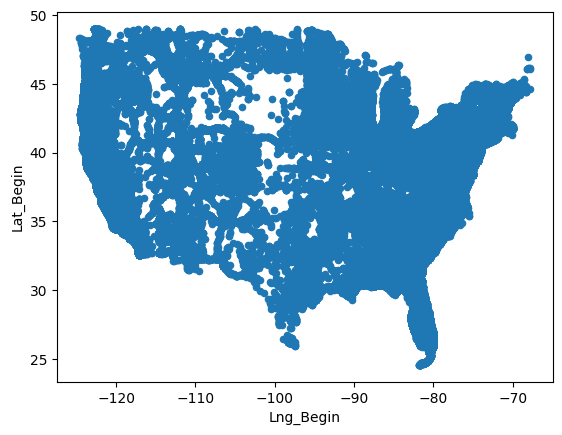

In [ ]:
df.plot.scatter(x='Lng_Begin', y='Lat_Begin')

he scatter plot shows the geographic distribution of accidents and helps identify areas with a high concentration of incidents.

**How do accident frequencies vary by time of day, day of the week, or season?**

In [ ]:
df['Hour'] = df['Incident_Start'].dt.hour
df['Hour'].value_counts().sort_index()

,count
Hour,
0,21540
1,18579
2,17521
3,15943
4,30238
5,43436
6,77025
7,112664
8,110386


### Insight
Accidents peak during the morning rush hour, with the highest number occurring at 7 AM

In [ ]:
df['Day'] = df['Incident_Start'].dt.day_name()
df['Day'].value_counts()

,count
Day,
Friday,260641
Wednesday,251076
Thursday,250529
Tuesday,245841
Monday,230979
Saturday,127258
Sunday,107669


### Insight
Friday has the highest number of accidents, while Sunday has the lowest

In [ ]:
df['Month'] = df['Incident_Start'].dt.month_name()
df['Month'].value_counts()

,count
Month,
December,161548
November,144924
January,143231
October,128787
February,125279
September,124641
August,114036
April,112439
June,108948


December has the highest number of accidents, while July has the lowest

In [ ]:
df['Month'] = df['Incident_Start'].dt.month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)
df['Season'].value_counts()

,count
Season,
Winter,430058
Fall,398352
Spring,324886
Summer,320697


### Insight
Winter has the highest number of accidents, while Summer has the lowest.

**How does traffic speed or speed limit impact accident likelihood?**

The dataset does not include traffic speed or speed limit data, so we cannot evaluate their effect on accidents


What are the peak hours for accidents, and how do they vary by day of week?

In [ ]:
peak_hours = df.groupby(['Day', 'Hour']).size().reset_index(name='Accidents')
peak_hours = peak_hours.loc[peak_hours.groupby('Day')['Accidents'].idxmax()]
peak_hours

,Day,Hour,Accidents
16,Friday,16,20966
31,Monday,7,19932
62,Saturday,14,8438
86,Sunday,14,6932
103,Thursday,7,21460
127,Tuesday,7,22625
151,Wednesday,7,22403


Peak accident hours vary by day of the week. Weekdays generally peak at 7 AM, while Friday peaks at 4 PM and weekends peak at 2 PM

**Are night-time accidents more severe than daytime ones?**

In [ ]:
df.groupby('Sunrise_Sunset')['Severity'].mean()

,Severity
Sunrise_Sunset,
Day,2.209252
Night,2.218926


### Insight
Night-time accidents have a slightly higher average severity than daytime accidents

**Which cities or regions report the highest number of accidents and severity levels ?**

In [ ]:
df['City_name'].value_counts().head(10)

,count
City_name,
Miami,35536
Houston,32528
Los Angeles,29836
Charlotte,26448
Dallas,24785
Orlando,20874
Austin,18635
Raleigh,16329
Nashville,13960


### Insight
Miami reports the highest number of accidents, followed by Houston and Los Angeles.

In [ ]:
df.groupby('City_name')['Severity'].mean().sort_values(ascending=False).head(10)

,Severity
City_name,
St Meinrad,4.0
St Mary,4.0
Coral Springs-Margate,4.0
Star Junction,4.0
Cornell,4.0
Mc Rae Helena,4.0
Colon,4.0
Spring Branch,4.0
Costilla,4.0


In [ ]:
city_analysis = df.groupby('City_name').agg(
    Accident_Count=('Record_ID', 'count'),
    Average_Severity=('Severity', 'mean')
)

city_analysis.sort_values('Accident_Count', ascending=False).head(10)

,Accident_Count,Average_Severity
City_name,,
Miami,35536,2.100236
Houston,32528,2.183780
Los Angeles,29836,2.231331
Charlotte,26448,2.042385
Dallas,24785,2.261448
Orlando,20874,2.066830
Austin,18635,2.092138
Raleigh,16329,2.089595
Nashville,13960,2.145774


### Insight
Miami has the highest number of accidents, while Dallas has the highest average severity among the top 10 cities.



### **Accidents by Weather Condition**

In [ ]:
df['Weather_Condition'].value_counts().head(10)

,count
Weather_Condition,
Fair,488581
Mostly Cloudy,193929
Cloudy,155810
Clear,154158
Partly Cloudy,133530
Overcast,72765
Light Rain,67168
Scattered Clouds,38964
Light Snow,24485


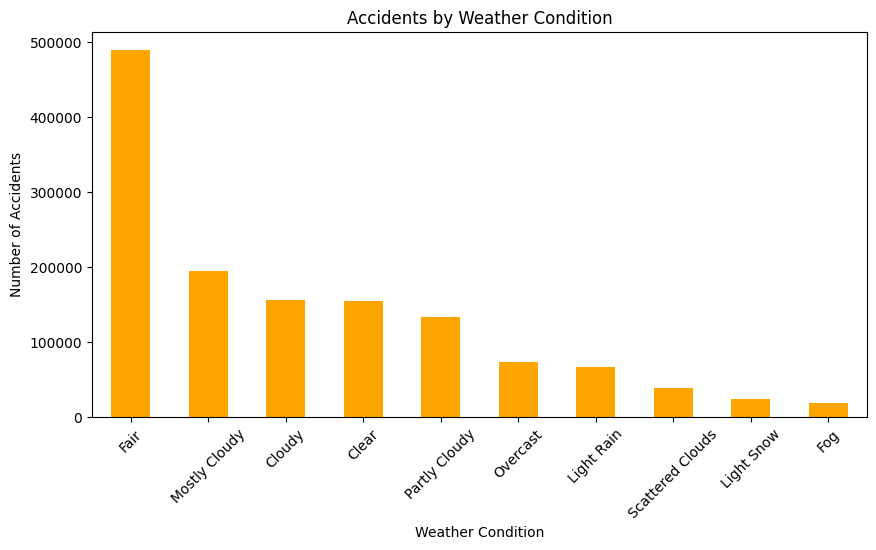

In [ ]:
import matplotlib.pyplot as plt

df['Weather_Condition'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5),
    color='orange'
)

plt.title('Accidents by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Severity'>

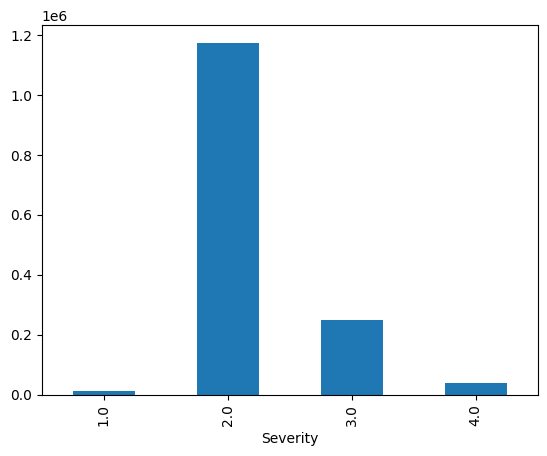

In [ ]:
df['Severity'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='Hour'>

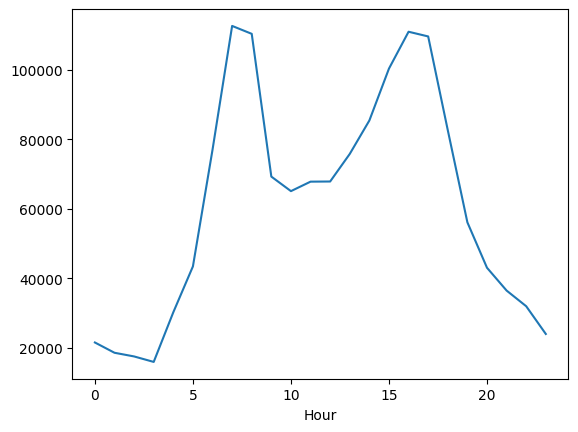

In [ ]:
df['Hour'].value_counts().sort_index().plot(kind='line')

Most accidents occurred under Fair weather conditions, followed by Mostly Cloudy and Cloudy conditions